# Spaceship Titanic — EDA & Data Visualization Pipeline (corrected copy)

A function-based exploratory analysis of the **Spaceship Titanic** dataset.

**Changes from the original notebook**
1. Every cell runs, including mutual information and the key findings.
2. Zero spending is split by CryoSleep and age, so it no longer just repeats the CryoSleep signal.
3. The spending-by-amenity claim is calculated from the data instead of typed in.
4. Missing spending is filled with 0 only where the data proves it (CryoSleep, age ≤ 12); `TotalSpend` needs all five amounts.
5. `FamilySize` (really "passengers sharing a surname") is removed.
6. Every key finding is calculated; nothing is hard-coded.
7. Cabin-number analysis is done within each deck, with a fixed random seed.
8. Category charts use one axis (rate bars, with n under each label) instead of two.
9. Groups with fewer than 30 passengers are left out of the rate charts and table.

**Pipeline**
1. Setup & data loading
2. Data overview
3. Missing-value analysis
4. Target distribution
5. Feature engineering for EDA (Cabin, Group, Spend)
6. Categorical features vs. target
7. Numerical features vs. target
8. Cabin position analysis
9. Feature interactions
10. Correlation analysis
11. Train vs. test distribution check (runs only if test.csv is available)
12. Feature relevance (mutual information)
13. Key findings

## 1. Setup & data loading

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

# ---------- Palette (colorblind-validated categorical order) ----------
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948")
CAT = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
TARGET_COLORS = {True: BLUE, False: ORANGE}          # Transported / Not transported
TARGET_LABELS = {True: "Transported", False: "Not transported"}
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"

SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ef8f8e", "#b52f2f"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "text.color": INK,
    "font.family": "sans-serif", "figure.dpi": 100,
})

RNG = np.random.default_rng(42)   # fixed seed so jittered plots are reproducible
MIN_COUNT = 30                     # smallest group shown in rate charts / tables

# Local files first (override with the TRAIN_CSV / TEST_CSV environment variables), then Kaggle's input folder.
TRAIN_CSV = os.environ.get("TRAIN_CSV", os.path.expanduser("~/Downloads/train (2).csv"))
TEST_CSV = os.environ.get("TEST_CSV", os.path.expanduser("~/Downloads/test.csv"))

def load_csv(local_path, kaggle_name, required=True):
    if os.path.exists(local_path):
        return pd.read_csv(local_path)
    hits = glob.glob(f"/kaggle/input/**/{kaggle_name}", recursive=True)
    if hits:
        return pd.read_csv(hits[0])
    if required:
        raise FileNotFoundError(f"{kaggle_name} not found: set TRAIN_CSV or attach the competition data.")
    return None

train = load_csv(TRAIN_CSV, "train.csv")
test = load_csv(TEST_CSV, "test.csv", required=False)
TARGET = "Transported"
print(f"train: {train.shape}   test: {test.shape if test is not None else 'not found (train-vs-test check skipped)'}")

train: (8693, 14)   test: not found (train-vs-test check skipped)


## 2. Data overview

In [2]:
def overview(df, name="df"):
    """Column-level summary: dtype, missing, unique values, and an example value."""
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
        "example": df.iloc[0],
    })
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} cols | "
          f"duplicates: {df.duplicated().sum()} | memory: {df.memory_usage(deep=True).sum()/1e6:.2f} MB")
    return out

display(train.head())
display(overview(train, "train"))

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


train: 8,693 rows × 14 cols | duplicates: 0 | memory: 3.54 MB


,dtype,missing,missing_%,unique,example
PassengerId,str,0,0.00,8693,0001_01
HomePlanet,str,201,2.31,3,Europa
CryoSleep,object,217,2.50,2,False
Cabin,str,199,2.29,6560,B/0/P
Destination,str,182,2.09,3,TRAPPIST-1e
Age,float64,179,2.06,80,39.0
VIP,object,203,2.34,2,False
RoomService,float64,181,2.08,1273,0.0
FoodCourt,float64,183,2.11,1507,0.0
ShoppingMall,float64,208,2.39,1115,0.0


In [3]:
NUM_COLS = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
CAT_COLS = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
display(train[NUM_COLS].describe().T.style.format("{:.1f}").background_gradient(cmap=SEQ, subset=["mean", "50%", "max"]))

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.8,14.5,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.7,666.7,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.1,1611.5,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.7,604.7,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.1,1136.7,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.9,1145.7,0.0,0.0,0.0,46.0,24133.0


## 3. Missing-value analysis

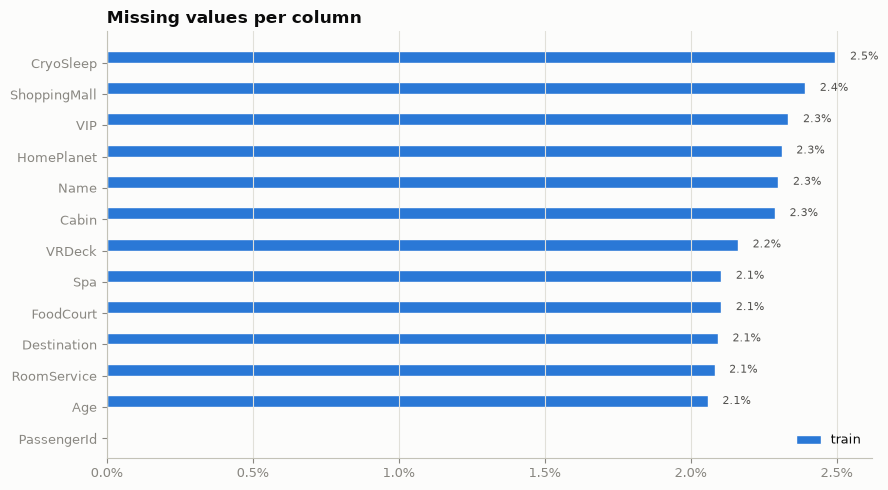

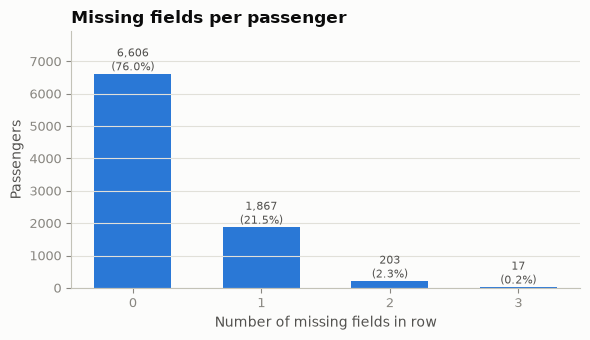

In [4]:
def plot_missing(train, test):
    """Side-by-side % missing per column for train and test."""
    cols = [c for c in train.columns if c != TARGET]
    m = pd.DataFrame({"train": train[cols].isna().mean() * 100})
    if test is not None:
        m["test"] = test[cols].isna().mean() * 100
    m = m.sort_values("train")
    fig, ax = plt.subplots(figsize=(9, 5))
    y = np.arange(len(m)); h = 0.38
    ax.barh(y + h/2, m["train"], h, color=BLUE, label="train", edgecolor=SURFACE, linewidth=1)
    if "test" in m:
        ax.barh(y - h/2, m["test"], h, color=ORANGE, label="test", edgecolor=SURFACE, linewidth=1)
    ax.set_yticks(y, m.index); ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    for yi, v in zip(y, m["train"]):
        if v > 0: ax.text(v + 0.05, yi + h/2, f"{v:.1f}%", va="center", fontsize=8, color=INK2)
    ax.set_title("Missing values per column"); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()

def plot_missing_per_row(df):
    """How many fields are missing in each passenger row."""
    counts = df.drop(columns=[TARGET], errors="ignore").isna().sum(axis=1).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(counts.index.astype(str), counts.values, color=BLUE, width=0.6)
    for x, v in zip(counts.index.astype(str), counts.values):
        ax.text(x, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom", fontsize=8, color=INK2)
    ax.set_xlabel("Number of missing fields in row"); ax.set_ylabel("Passengers")
    ax.set_title("Missing fields per passenger"); ax.margins(y=0.2)
    plt.tight_layout(); plt.show()

plot_missing(train, test)
plot_missing_per_row(train)

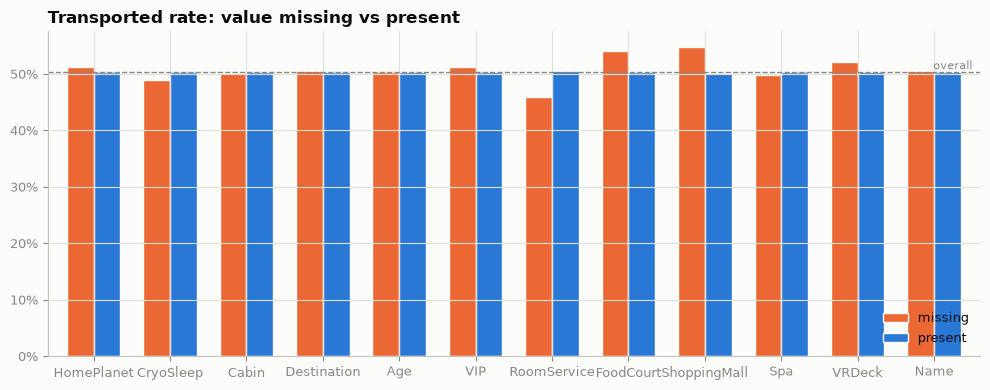

In [5]:
def plot_missing_vs_target(df, cols):
    """Transported rate when a value is missing vs present — is missingness informative?"""
    rows = []
    for c in cols:
        miss = df[c].isna()
        if miss.sum() == 0: continue
        rows.append({"col": c, "missing": df.loc[miss, TARGET].mean(), "present": df.loc[~miss, TARGET].mean()})
    r = pd.DataFrame(rows).set_index("col")
    ax = r.plot.bar(color=[ORANGE, BLUE], figsize=(10, 4), width=0.7, edgecolor=SURFACE, linewidth=1)
    ax.axhline(df[TARGET].mean(), color=MUTED, ls="--", lw=1)
    ax.text(len(r) - 0.5, df[TARGET].mean(), " overall", va="bottom", ha="right", color=MUTED, fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_xlabel("")
    ax.set_title("Transported rate: value missing vs present"); plt.xticks(rotation=0); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

plot_missing_vs_target(train, [c for c in train.columns if c not in ("PassengerId", TARGET)])

## 4. Target distribution

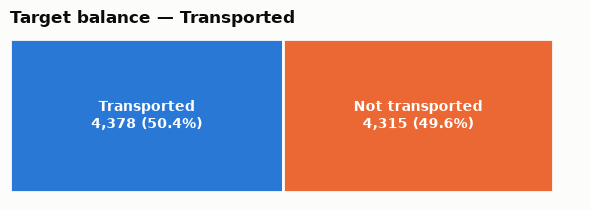

In [6]:
def plot_target(df):
    counts = df[TARGET].value_counts().reindex([True, False])
    fig, ax = plt.subplots(figsize=(6, 2.2))
    left = 0
    for k, v in counts.items():
        ax.barh(0, v, left=left, color=TARGET_COLORS[k], edgecolor=SURFACE, linewidth=2)
        ax.text(left + v/2, 0, f"{TARGET_LABELS[k]}\n{v:,} ({v/len(df):.1%})", ha="center", va="center",
                color="white", fontsize=10, fontweight="bold")
        left += v
    ax.axis("off"); ax.set_title("Target balance — Transported")
    plt.tight_layout(); plt.show()

plot_target(train)

The target is almost perfectly balanced, so accuracy is a fair metric and no resampling is needed.

## 5. Feature engineering for EDA
`PassengerId` = `gggg_pp` (group / member), `Cabin` = `deck/num/side`, `Name` = `First Last`.

Missing spending is set to 0 only for passengers the data proves never spend (CryoSleep, age ≤ 12; checked below). `TotalSpend` is left missing unless all five amounts are known, so a missing amount is never treated as 0.

In [7]:
def spend_rules(df):
    """Check the two zero-spend rules before relying on them."""
    spent = df[SPEND_COLS].gt(0).any(axis=1)
    cryo, kids = df["CryoSleep"].eq(True), df["Age"].le(12)
    return pd.DataFrame({
        "passengers": [cryo.sum(), kids.sum()],
        "any spending > 0": [(cryo & spent).sum(), (kids & spent).sum()],
        "missing spend cells": [df.loc[cryo, SPEND_COLS].isna().sum().sum(), df.loc[kids & ~cryo, SPEND_COLS].isna().sum().sum()],
    }, index=["CryoSleep = True", "Age <= 12"])

def engineer(df):
    """Derive the features the raw columns are hiding."""
    d = df.copy()
    d["Group"] = d["PassengerId"].str.split("_").str[0].astype(int)
    d["GroupSize"] = d.groupby("Group")["Group"].transform("size")
    d["Solo"] = d["GroupSize"].eq(1)
    cab = d["Cabin"].str.split("/", expand=True)
    d["Deck"], d["CabinNum"], d["Side"] = cab[0], pd.to_numeric(cab[1]), cab[2]
    never_spend = d["CryoSleep"].eq(True) | d["Age"].le(12)
    d.loc[never_spend, SPEND_COLS] = d.loc[never_spend, SPEND_COLS].fillna(0)
    d["TotalSpend"] = d[SPEND_COLS].sum(axis=1, min_count=len(SPEND_COLS))   # NaN unless all 5 known
    d["NoSpend"] = d["TotalSpend"].eq(0).where(d["TotalSpend"].notna())     # True / False / NaN
    d["Surname"] = d["Name"].str.split().str[-1]
    d["AgeGroup"] = pd.cut(d["Age"], [-1, 4, 12, 17, 25, 35, 50, 80],
                           labels=["0-4", "5-12", "13-17", "18-25", "26-35", "36-50", "51+"])
    return d

display(spend_rules(train))
tr = engineer(train)
te = engineer(test) if test is not None else None
tr[["PassengerId", "Group", "GroupSize", "Deck", "CabinNum", "Side", "TotalSpend", "NoSpend", "AgeGroup"]].head()

,passengers,any spending > 0,missing spend cells
CryoSleep = True,3037,0,361
Age <= 12,806,0,45


,PassengerId,Group,GroupSize,Deck,CabinNum,Side,TotalSpend,NoSpend,AgeGroup
0,0001_01,1,1,B,0.0,P,0.0,True,36-50
1,0002_01,2,1,F,0.0,S,736.0,False,18-25
2,0003_01,3,2,A,0.0,S,10383.0,False,51+
3,0003_02,3,2,A,0.0,S,5176.0,False,26-35
4,0004_01,4,1,F,1.0,S,1091.0,False,13-17


## 6. Categorical features vs. target
Each panel shows the **transported rate** per category on a single axis, with the passenger count under each label. The dashed line is the overall rate. Categories with fewer than 30 passengers are left out.

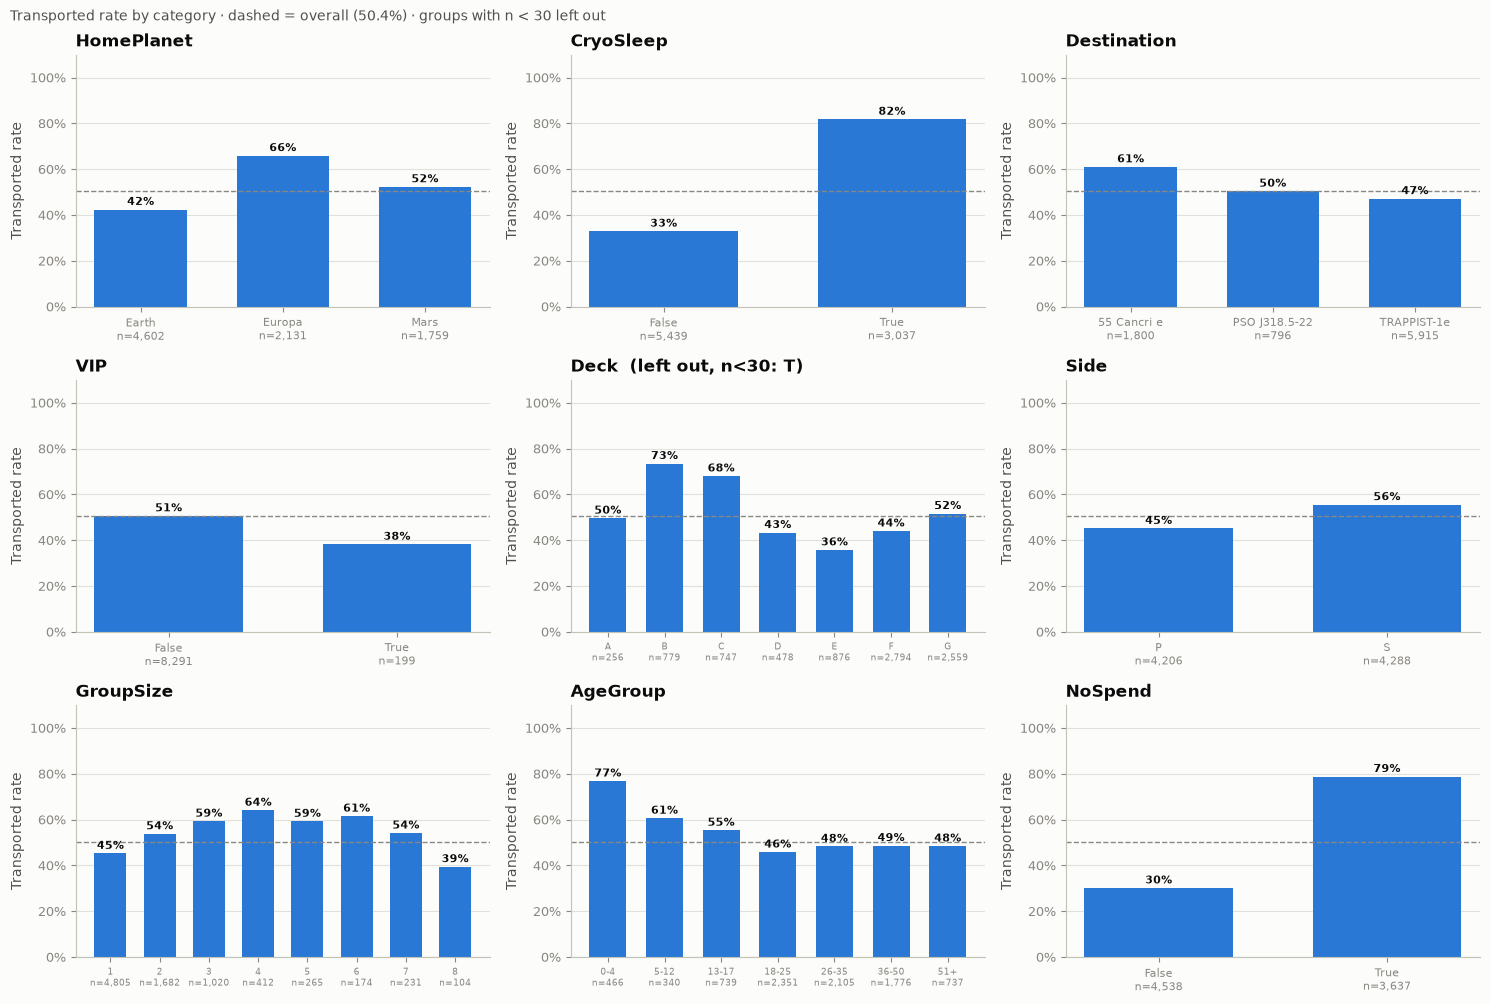

In [8]:
def plot_rate_by(df, col, ax=None, order=None, min_count=MIN_COUNT):
    """Transported-rate bars for one categorical column (single axis; n shown under each label)."""
    g = df.groupby(col, observed=True)[TARGET].agg(["size", "mean"])
    dropped = g.index[g["size"] < min_count].tolist()
    g = g[g["size"] >= min_count]
    if order is not None: g = g.reindex([o for o in order if o in g.index])
    ax = ax or plt.gca()
    x = np.arange(len(g))
    ax.bar(x, g["mean"], color=BLUE, width=0.65)
    for xi, v in zip(x, g["mean"]):
        ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=8, color=INK, fontweight="bold")
    ax.axhline(df[TARGET].mean(), color=MUTED, ls="--", lw=1)
    ax.set_xticks(x, [f"{i}\nn={n:,}" for i, n in zip(g.index, g["size"])], fontsize=8 if len(g) <= 6 else 6.5)
    ax.set_axisbelow(True)   # keep grid lines behind the bars
    ax.set_ylim(0, 1.1); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Transported rate"); ax.set_xlabel("")
    ax.set_title(col + (f"  (left out, n<{min_count}: {', '.join(map(str, dropped))})" if dropped else ""))
    return ax

def rate_grid(df, cols, ncols=3, orders=None, figsize_per=(5, 3.4)):
    orders = orders or {}
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    for ax, c in zip(np.ravel(axes), cols): plot_rate_by(df, c, ax=ax, order=orders.get(c))
    for ax in np.ravel(axes)[len(cols):]: ax.set_visible(False)
    fig.suptitle(f"Transported rate by category · dashed = overall ({df[TARGET].mean():.1%}) · groups with n < {MIN_COUNT} left out",
                 x=0.01, ha="left", fontsize=10, color=INK2)
    plt.tight_layout(); plt.show()

rate_grid(tr, ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side",
               "GroupSize", "AgeGroup", "NoSpend"],
          orders={"Deck": list("ABCDEFGT")})

In [9]:
def rate_table(df, cols, min_count=MIN_COUNT):
    """Tabular view of the same numbers — sorted by lift over the base rate (groups with n < min_count left out)."""
    base = df[TARGET].mean(); out = []
    for c in cols:
        g = df.groupby(c, observed=True)[TARGET].agg(count="size", rate="mean").reset_index().rename(columns={c: "value"})
        g.insert(0, "feature", c); out.append(g)
    t = pd.concat(out, ignore_index=True)
    t = t[t["count"] >= min_count]
    t["lift"] = t["rate"] - base
    return t.sort_values("lift", key=abs, ascending=False).head(15).style.format(
        {"rate": "{:.1%}", "lift": "{:+.1%}"}).background_gradient(cmap=DIV.reversed(), subset=["lift"], vmin=-0.4, vmax=0.4)

rate_table(tr, ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side", "GroupSize", "AgeGroup", "NoSpend"])

,feature,value,count,rate,lift
4,CryoSleep,True,3037,81.8%,+31.4%
36,NoSpend,True,3637,78.8%,+28.4%
28,AgeGroup,0-4,466,76.8%,+26.5%
11,Deck,B,779,73.4%,+23.1%
35,NoSpend,False,4538,30.1%,-20.2%
12,Deck,C,747,68.0%,+17.6%
3,CryoSleep,False,5439,32.9%,-17.5%
1,HomePlanet,Europa,2131,65.9%,+15.5%
14,Deck,E,876,35.7%,-14.6%
23,GroupSize,4,412,64.1%,+13.7%


## 7. Numerical features vs. target

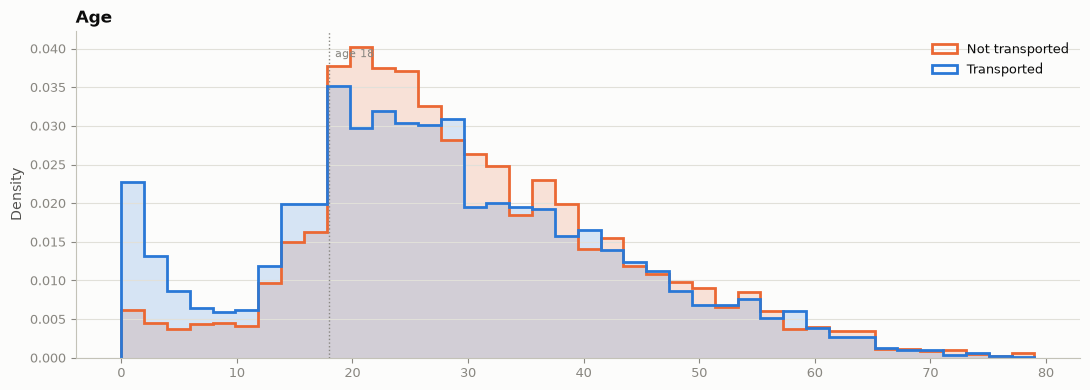

In [10]:
def plot_dist_by_target(df, col, ax=None, bins=40, log=False):
    """Overlaid histograms (density) by target class."""
    ax = ax or plt.gca()
    s = df[[col, TARGET]].dropna()
    vals = np.log1p(s[col]) if log else s[col]
    edges = np.histogram_bin_edges(vals, bins=bins)
    for k in (False, True):
        v = vals[s[TARGET] == k]
        ax.hist(v, bins=edges, density=True, histtype="stepfilled", alpha=0.18, color=TARGET_COLORS[k])
        ax.hist(v, bins=edges, density=True, histtype="step", lw=2, color=TARGET_COLORS[k], label=TARGET_LABELS[k])
    ax.set_title(f"{col}{' (log1p)' if log else ''}"); ax.set_ylabel("Density")
    return ax

fig, ax = plt.subplots(figsize=(11, 4))
plot_dist_by_target(tr, "Age", ax=ax, bins=40)
ax.axvline(18, color=MUTED, ls=":", lw=1); ax.text(18.5, ax.get_ylim()[1]*0.92, "age 18", color=MUTED, fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

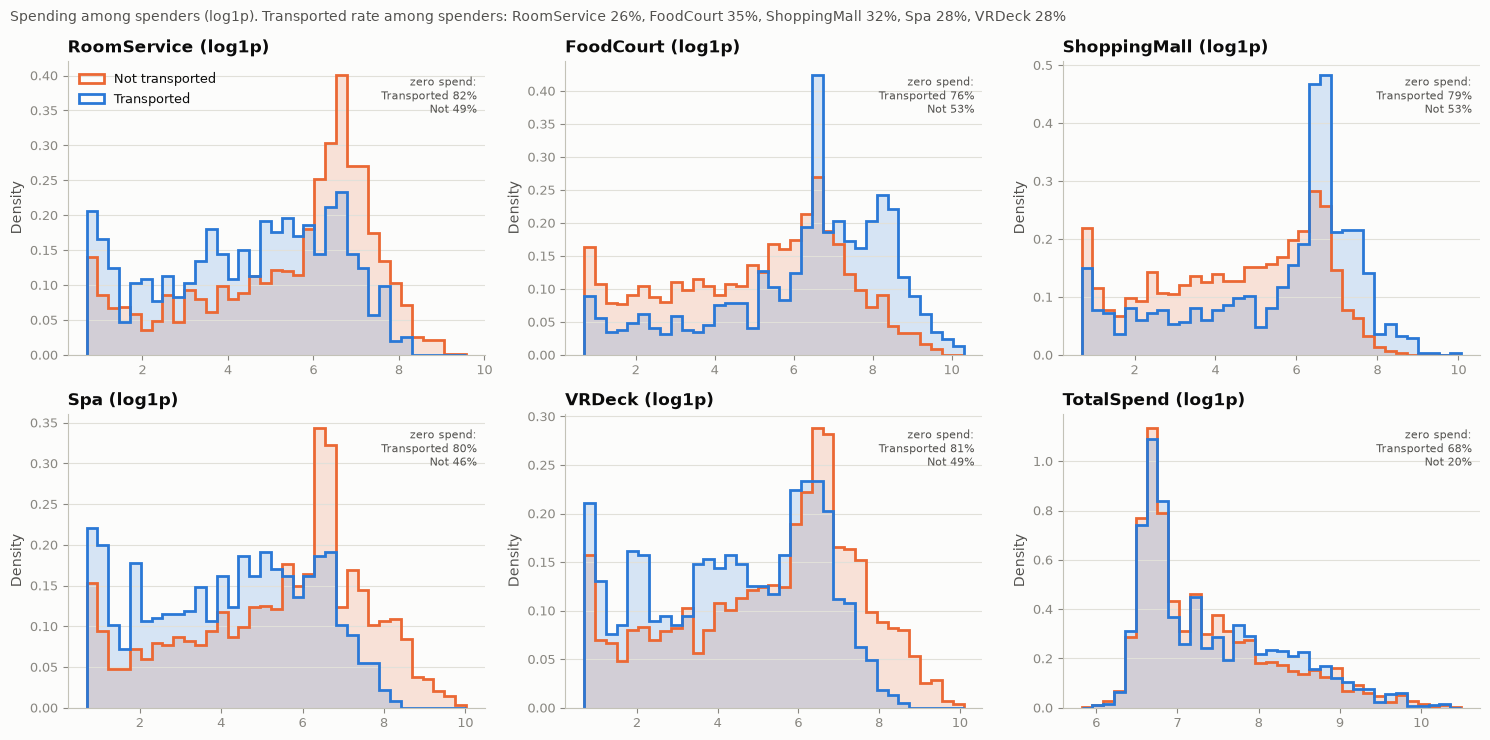

,n,rate
RoomService,"2,935",26.0%
FoodCourt,"3,054",34.5%
ShoppingMall,"2,898",31.7%
Spa,"3,186",27.7%
VRDeck,"3,010",27.5%


In [11]:
def spender_rates(df):
    """Transported rate among passengers who spent > 0 on each amenity (and n)."""
    return pd.DataFrame({c: {"n": int((df[c] > 0).sum()), "rate": df.loc[df[c] > 0, TARGET].mean()} for c in SPEND_COLS}).T

def spend_panels(df):
    """Spending (log1p, spenders only) by target + share of zero-spenders per amenity."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
    for ax, c in zip(axes.ravel(), SPEND_COLS + ["TotalSpend"]):
        sub = df[df[c] > 0]
        plot_dist_by_target(sub, c, ax=ax, log=True, bins=35)
        zero = df.loc[df[c].notna()]
        z_t = (zero.loc[zero[TARGET], c] == 0).mean(); z_f = (zero.loc[~zero[TARGET], c] == 0).mean()
        ax.text(0.98, 0.95, f"zero spend:\nTransported {z_t:.0%}\nNot {z_f:.0%}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color=INK2)
    axes[0, 0].legend(loc="upper left")
    sr = spender_rates(df)
    fig.suptitle("Spending among spenders (log1p). Transported rate among spenders: "
                 + ", ".join(f"{c} {r:.0%}" for c, r in sr["rate"].items()),
                 x=0.01, ha="left", fontsize=10, color=INK2)
    plt.tight_layout(); plt.show()

spend_panels(tr)
display(spender_rates(tr).style.format({"n": "{:,.0f}", "rate": "{:.1%}"}))

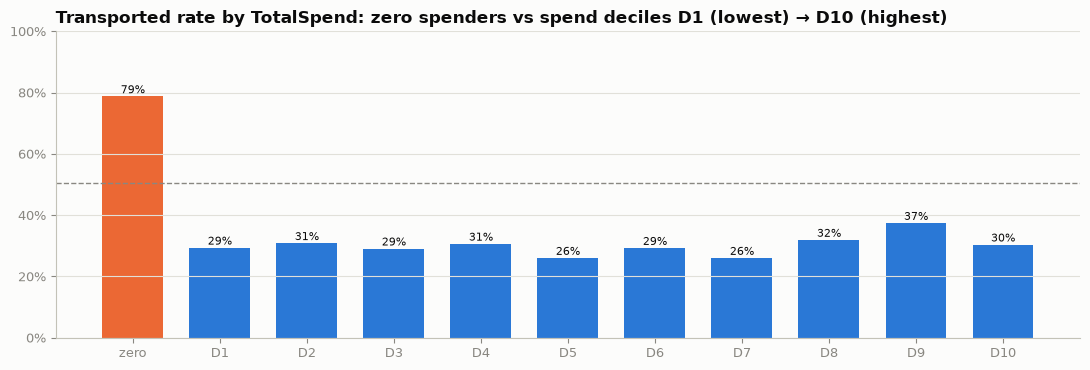

In [12]:
def plot_spend_rate(df, col="TotalSpend", q=10):
    """Transported rate across spend deciles (zero spenders as their own bucket)."""
    d = df[[col, TARGET]].dropna().copy()
    d["bucket"] = "0"
    pos = d[col] > 0
    d.loc[pos, "bucket"] = pd.qcut(d.loc[pos, col], q, duplicates="drop").astype(str)
    g = d.groupby("bucket", sort=False)[TARGET].agg(["size", "mean"])
    order = ["0"] + sorted([b for b in g.index if b != "0"], key=lambda s: float(s.split(",")[0].strip("(")))
    g = g.loc[order]
    fig, ax = plt.subplots(figsize=(11, 3.8))
    colors = [ORANGE if b == "0" else BLUE for b in g.index]
    ax.bar(range(len(g)), g["mean"], color=colors, width=0.7)
    ax.set_xticks(range(len(g)), ["zero"] + [f"D{i}" for i in range(1, len(g))])
    for i, (v, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontsize=8, color=INK)
    ax.axhline(df[TARGET].mean(), color=MUTED, ls="--", lw=1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0, 1)
    ax.set_title(f"Transported rate by {col}: zero spenders vs spend deciles D1 (lowest) → D{len(g)-1} (highest)")
    plt.tight_layout(); plt.show()

plot_spend_rate(tr)

## 8. Cabin position analysis
Cabin numbers run along each deck, but their range differs a lot by deck (deck A stops near 100, deck F goes past 1,800). A rolling rate across all decks would partly reflect which deck a cabin is on, so the rate is computed **within each deck**.

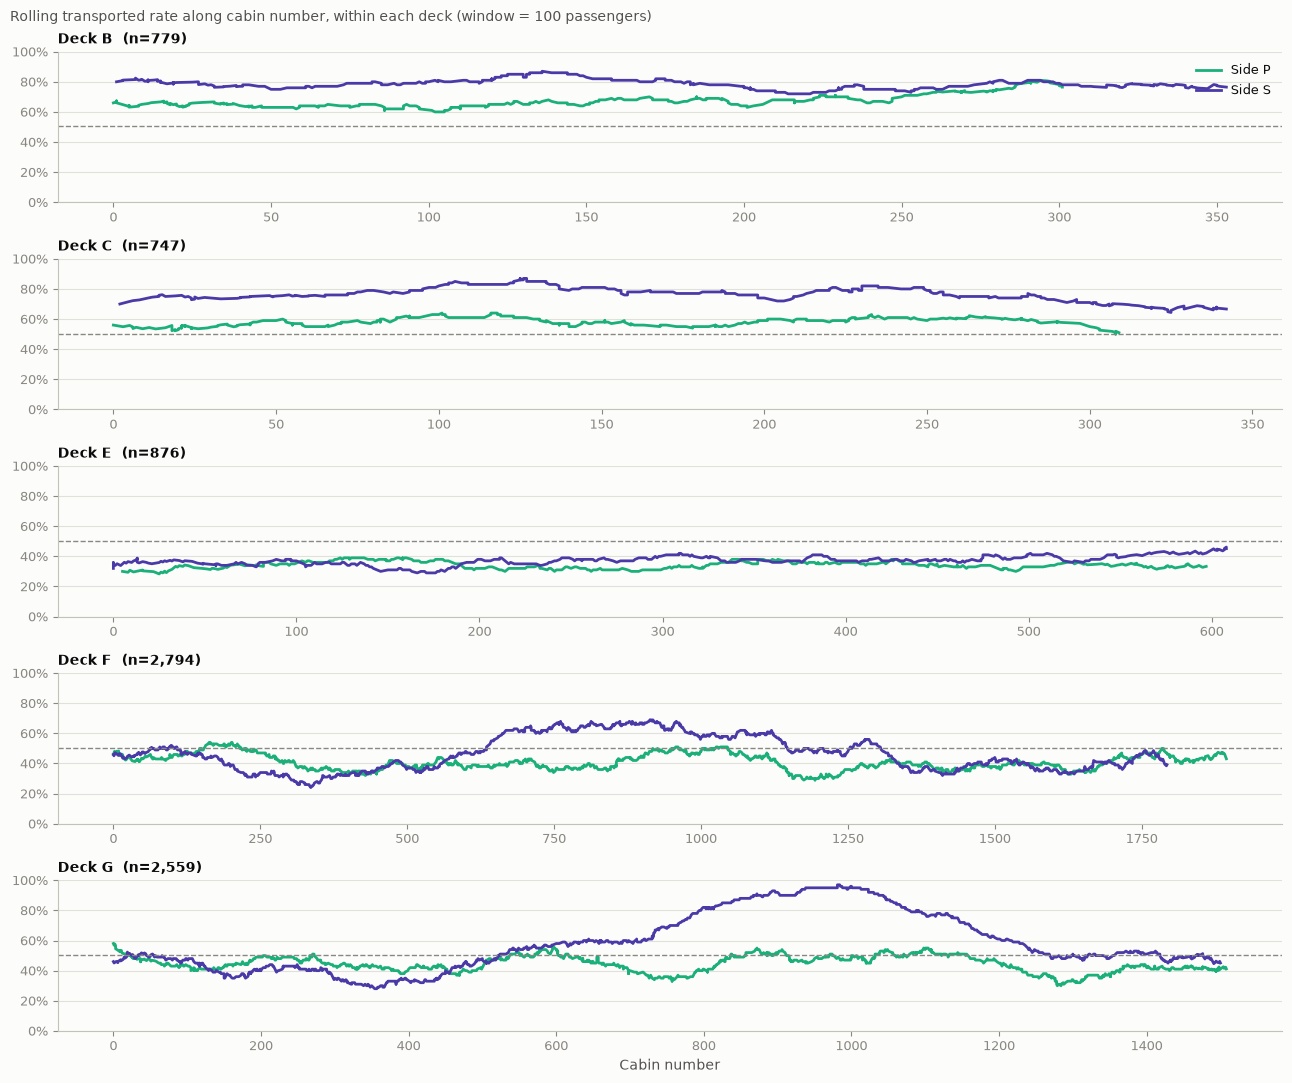

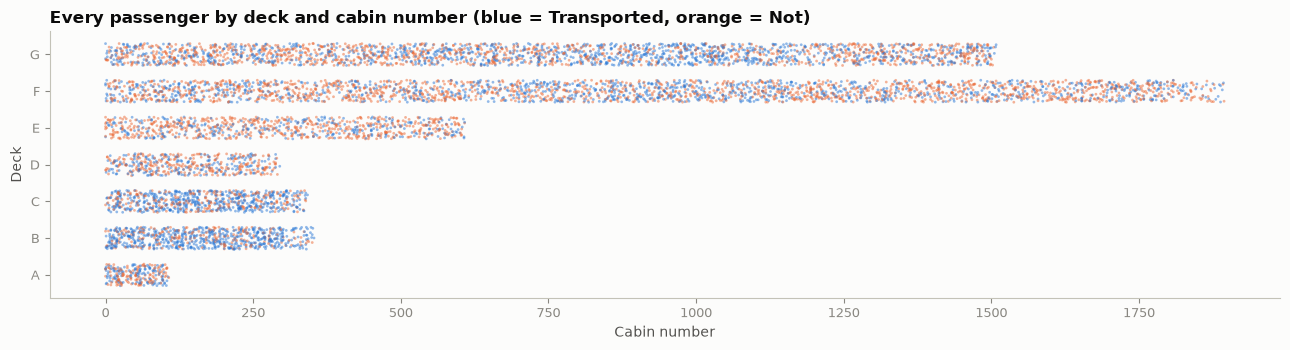

,lowest fifth,highest fifth,spread (points)
B,70.3%,78.2%,7.9
C,63.6%,74.5%,10.9
E,33.5%,37.9%,4.4
F,40.3%,53.6%,13.3
G,42.4%,69.1%,26.7


In [13]:
BIG_DECKS = ["B", "C", "E", "F", "G"]   # decks with 700+ passengers

def plot_cabin_position(df, window=100, decks=BIG_DECKS):
    d = df.dropna(subset=["CabinNum"])
    fig, axes = plt.subplots(len(decks), 1, figsize=(13, 2.2 * len(decks)), sharey=True)
    for ax, deck in zip(axes, decks):
        for side, color in [("P", AQUA), ("S", VIOLET)]:
            s = d[(d["Deck"] == deck) & (d["Side"] == side)].sort_values("CabinNum")
            roll = s[TARGET].astype(float).rolling(window, center=True, min_periods=window // 2).mean()
            ax.plot(s["CabinNum"], roll, color=color, lw=2, label=f"Side {side}")
        ax.axhline(df[TARGET].mean(), color=MUTED, ls="--", lw=1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0, 1)
        ax.set_title(f"Deck {deck}  (n={int((d['Deck'] == deck).sum()):,})", fontsize=10)
    axes[0].legend(loc="upper right"); axes[-1].set_xlabel("Cabin number")
    fig.suptitle(f"Rolling transported rate along cabin number, within each deck (window = {window} passengers)",
                 x=0.01, ha="left", fontsize=10, color=INK2)
    plt.tight_layout(); plt.show()

def plot_cabin_scatter(df):
    d = df.dropna(subset=["CabinNum"])
    fig, ax = plt.subplots(figsize=(13, 3.6))
    for k, deck in enumerate(list("ABCDEFG")):
        s = d[d["Deck"] == deck]
        ax.scatter(s["CabinNum"], np.full(len(s), k) + RNG.uniform(-0.3, 0.3, len(s)),
                   c=s[TARGET].map(TARGET_COLORS), s=4, alpha=0.5, linewidths=0)
    ax.set_yticks(range(7), list("ABCDEFG")); ax.set_ylabel("Deck"); ax.grid(False)
    ax.set_xlabel("Cabin number"); ax.set_title("Every passenger by deck and cabin number (blue = Transported, orange = Not)")
    plt.tight_layout(); plt.show()

def cabin_zone_summary(df, decks=BIG_DECKS, bins=5):
    """Transported rate by cabin-number fifth within each deck: lowest and highest fifth."""
    rows = {}
    for deck in decks:
        s = df[df["Deck"] == deck].dropna(subset=["CabinNum"])
        r = s.groupby(pd.qcut(s["CabinNum"], bins, duplicates="drop"), observed=True)[TARGET].mean()
        rows[deck] = {"lowest fifth": r.min(), "highest fifth": r.max(), "spread (points)": (r.max() - r.min()) * 100}
    return pd.DataFrame(rows).T

plot_cabin_position(tr)
plot_cabin_scatter(tr)
display(cabin_zone_summary(tr).style.format({"lowest fifth": "{:.1%}", "highest fifth": "{:.1%}", "spread (points)": "{:.1f}"}))

## 9. Feature interactions

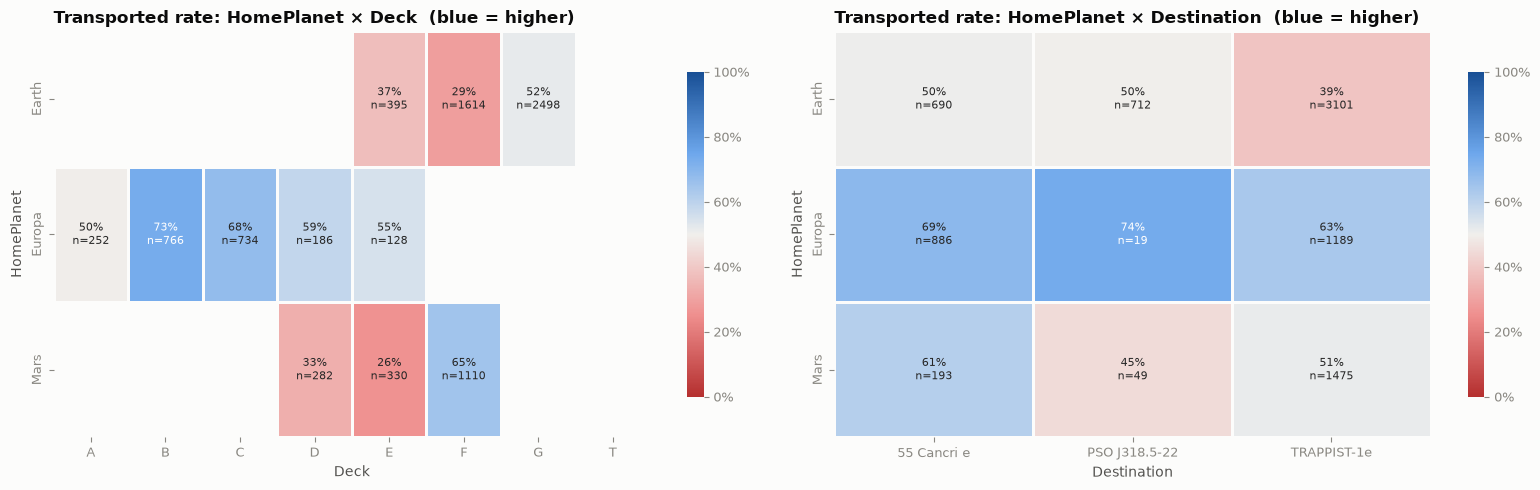

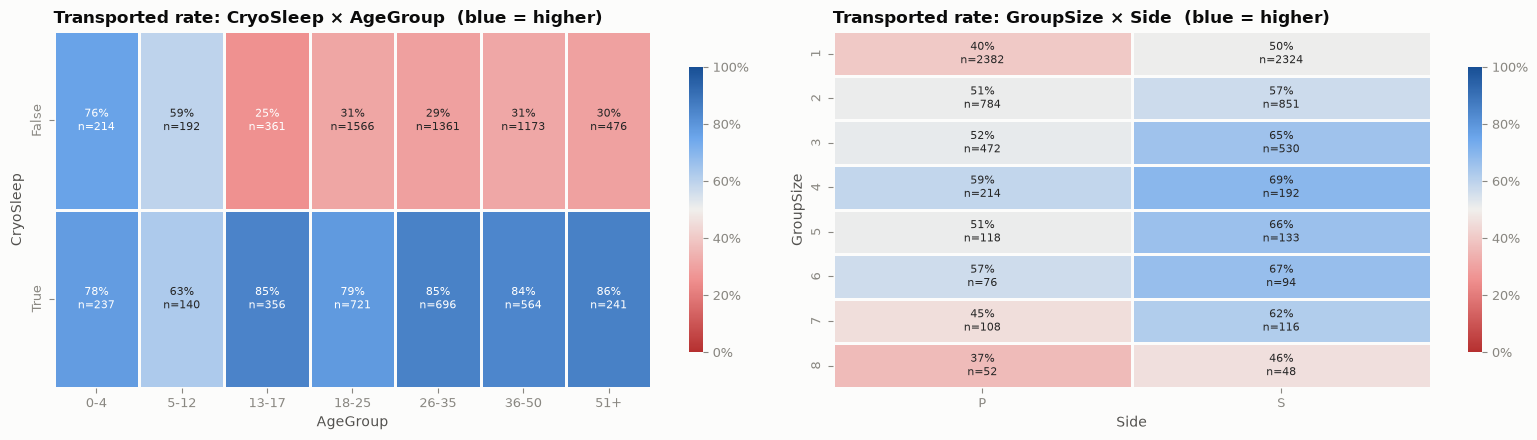

In [14]:
def rate_heatmap(df, row, col, ax=None, min_count=10):
    """Transported rate for every row×col combination; cells with < min_count passengers are blanked."""
    ax = ax or plt.gca()
    rate = df.pivot_table(index=row, columns=col, values=TARGET, aggfunc="mean", observed=True)
    n = df.pivot_table(index=row, columns=col, values=TARGET, aggfunc="size", observed=True)
    rate = rate.where(n >= min_count)
    annot = rate.map(lambda v: "" if pd.isna(v) else f"{v:.0%}") + n.map(lambda v: "" if pd.isna(v) else f"\nn={int(v)}").where(rate.notna(), "")
    sns.heatmap(rate, ax=ax, cmap=DIV.reversed(), vmin=0, vmax=1, center=0.5, annot=annot, fmt="", linewidths=2,
                linecolor=SURFACE, cbar_kws={"format": mtick.PercentFormatter(1.0), "shrink": 0.8},
                annot_kws={"fontsize": 8})
    ax.set_title(f"Transported rate: {row} × {col}  (blue = higher)"); ax.grid(False)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rate_heatmap(tr, "HomePlanet", "Deck", ax=axes[0])
rate_heatmap(tr, "HomePlanet", "Destination", ax=axes[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
rate_heatmap(tr, "CryoSleep", "AgeGroup", ax=axes[0])
rate_heatmap(tr, "GroupSize", "Side", ax=axes[1])
plt.tight_layout(); plt.show()

In [15]:
def cryo_spend_check(df):
    """Passengers in CryoSleep are confined to their cabins — do they ever spend money?"""
    return pd.crosstab(df["CryoSleep"], df["NoSpend"].map({True: "Spent 0", False: "Spent > 0"}), margins=True)

display(cryo_spend_check(tr))
print("→ CryoSleep=True passengers never spend: missing spend values for sleepers can be filled with 0, "
      "and NoSpend can help impute missing CryoSleep.")

NoSpend,Spent 0,Spent > 0,All
CryoSleep,,,
False,507,4432,4939
True,3037,0,3037
All,3544,4432,7976


→ CryoSleep=True passengers never spend: missing spend values for sleepers can be filled with 0, and NoSpend can help impute missing CryoSleep.


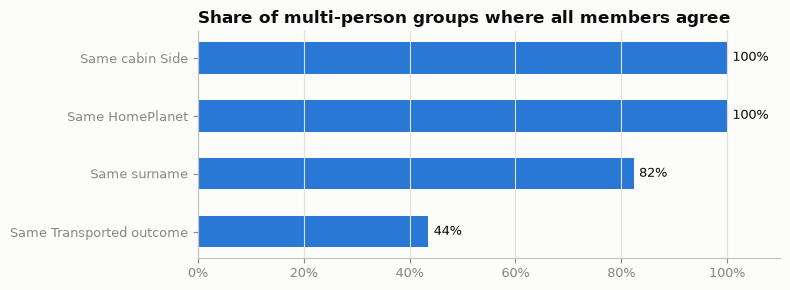

In [16]:
def plot_group_consistency(df):
    """Within groups of 2+, do members share the same outcome / HomePlanet?"""
    g = df[df["GroupSize"] > 1].groupby("Group")
    same_target = g[TARGET].nunique().eq(1).mean()
    same_planet = g["HomePlanet"].nunique().le(1).mean()
    same_side = g["Side"].nunique().le(1).mean()
    same_surname = g["Surname"].nunique().le(1).mean()
    s = pd.Series({"Same HomePlanet": same_planet, "Same cabin Side": same_side,
                   "Same Transported outcome": same_target, "Same surname": same_surname}).sort_values()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.barh(s.index, s.values, color=BLUE, height=0.55)
    for i, v in enumerate(s.values): ax.text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=9)
    ax.set_xlim(0, 1.1); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_title("Share of multi-person groups where all members agree")
    plt.tight_layout(); plt.show()

plot_group_consistency(tr)

## 10. Correlation analysis

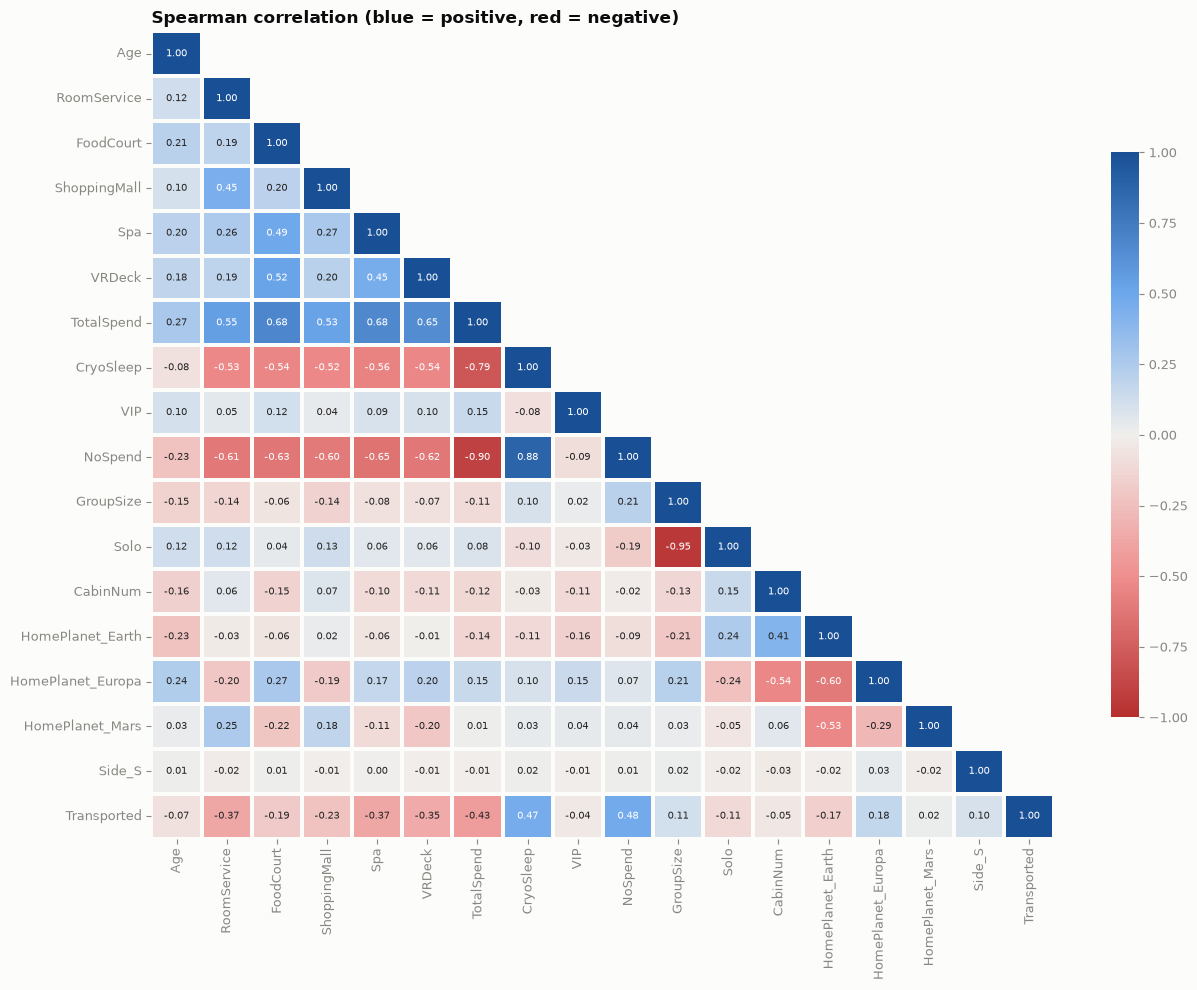

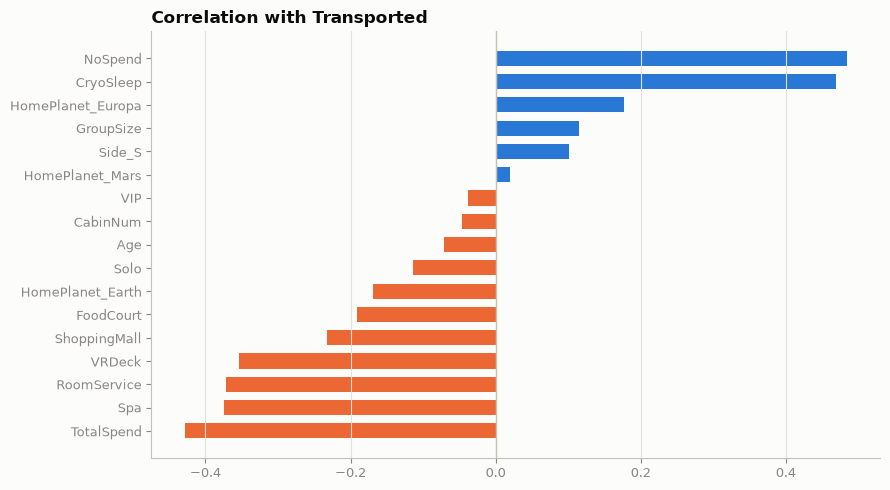

In [17]:
def plot_correlation(df):
    d = df.copy()
    for c in ["CryoSleep", "VIP", TARGET, "NoSpend", "Solo"]: d[c] = d[c].astype(float)
    d = pd.concat([d, pd.get_dummies(d[["HomePlanet", "Side"]], dtype=float)], axis=1)
    cols = ["Age", *SPEND_COLS, "TotalSpend", "CryoSleep", "VIP", "NoSpend", "GroupSize", "Solo", "CabinNum",
            "HomePlanet_Earth", "HomePlanet_Europa", "HomePlanet_Mars", "Side_S", TARGET]
    corr = d[cols].corr(method="spearman")
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    fig, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(corr, mask=mask, cmap=DIV.reversed(), vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
                annot_kws={"fontsize": 7}, linewidths=1.5, linecolor=SURFACE, cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title("Spearman correlation (blue = positive, red = negative)"); ax.grid(False)
    plt.tight_layout(); plt.show()
    return corr[TARGET].drop(TARGET).sort_values()

target_corr = plot_correlation(tr)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(target_corr.index, target_corr.values, color=[BLUE if v > 0 else ORANGE for v in target_corr.values], height=0.65)
ax.axvline(0, color=AXIS, lw=1); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Correlation with Transported"); plt.tight_layout(); plt.show()

## 11. Train vs. test distribution check
If train and test differ, validation scores will mislead.

In [18]:
def compare_train_test(tr, te, num_cols, cat_cols):
    fig, axes = plt.subplots(2, max(len(num_cols), len(cat_cols)), figsize=(4 * max(len(num_cols), len(cat_cols)), 7))
    for ax, c in zip(axes[0], num_cols):
        a, b = tr[c].dropna(), te[c].dropna()
        if c != "Age": a, b = np.log1p(a), np.log1p(b)
        edges = np.histogram_bin_edges(pd.concat([a, b]), bins=30)
        ax.hist(a, bins=edges, density=True, alpha=0.55, color=BLUE, label="train")
        ax.hist(b, bins=edges, density=True, alpha=0.55, color=ORANGE, label="test")
        ax.set_title(c + ("" if c == "Age" else " (log1p)"))
    for ax, c in zip(axes[1], cat_cols):
        p = pd.DataFrame({"train": tr[c].value_counts(normalize=True), "test": te[c].value_counts(normalize=True)}).sort_index()
        x = np.arange(len(p)); w = 0.38
        ax.bar(x - w/2, p["train"], w, color=BLUE, label="train"); ax.bar(x + w/2, p["test"], w, color=ORANGE, label="test")
        ax.set_xticks(x, p.index.astype(str), rotation=0); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_title(c)
    for ax in axes.ravel():
        if not ax.has_data(): ax.set_visible(False)
    axes[0, 0].legend()
    plt.tight_layout(); plt.show()

def max_share_gap(tr, te, cat_cols):
    """Largest difference (percentage points) in any category's share between train and test."""
    gaps = {c: (tr[c].value_counts(normalize=True) - te[c].value_counts(normalize=True)).abs().max() * 100 for c in cat_cols}
    return pd.Series(gaps).sort_values(ascending=False)

TT_CATS = ["HomePlanet", "CryoSleep", "Destination", "Deck", "Side"]
if te is not None:
    compare_train_test(tr, te, ["Age", "TotalSpend", "Spa", "FoodCourt", "GroupSize"], TT_CATS)
    tt_gap = max_share_gap(tr, te, TT_CATS)
    display(tt_gap.round(2).rename("max share gap (points)"))
else:
    tt_gap = None
    print("test.csv not found: train-vs-test check skipped. Download it from the Kaggle competition's Data tab and set TEST_CSV.")

test.csv not found: train-vs-test check skipped. Download it from the Kaggle competition's Data tab and set TEST_CSV.


## 12. Feature relevance — mutual information

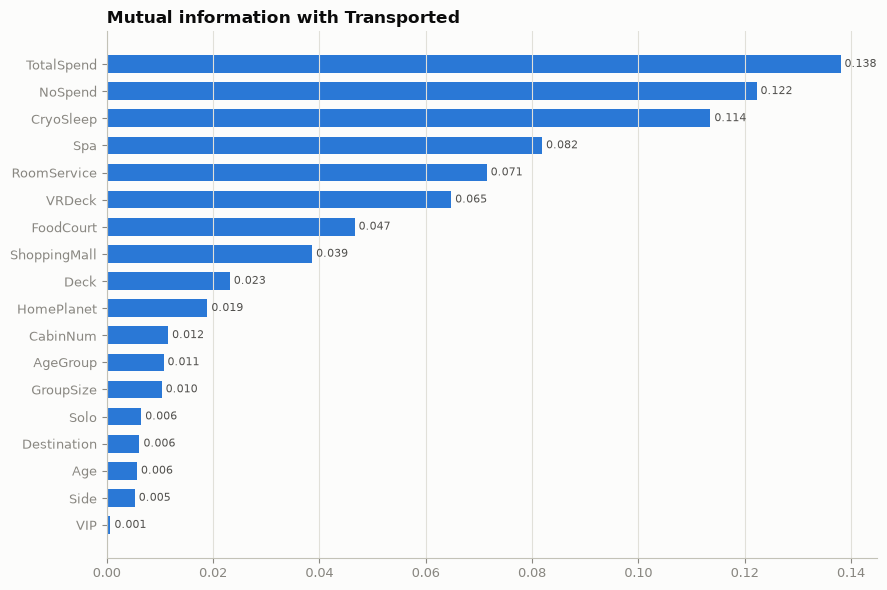

In [19]:
def mutual_info(df, features):
    """Mutual information with the target (categoricals label-encoded, NaN as its own code)."""
    X = pd.DataFrame(index=df.index)
    discrete = []
    for f in features:
        s = df[f]
        if pd.api.types.is_bool_dtype(s) or not pd.api.types.is_numeric_dtype(s):
            X[f] = s.astype(str).factorize()[0]; discrete.append(True)
        else:
            X[f] = s.fillna(s.median()); discrete.append(False)
    mi = mutual_info_classif(X, df[TARGET], discrete_features=discrete, random_state=42)
    s = pd.Series(mi, index=features).sort_values()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(s.index, s.values, color=BLUE, height=0.65)
    for i, v in enumerate(s.values): ax.text(v, i, f" {v:.3f}", va="center", fontsize=8, color=INK2)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False); ax.set_title("Mutual information with Transported")
    plt.tight_layout(); plt.show()
    return s.sort_values(ascending=False)

mi = mutual_info(tr, ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP", *SPEND_COLS, "TotalSpend", "NoSpend",
                      "Deck", "CabinNum", "Side", "GroupSize", "Solo", "AgeGroup"])

## 13. Key findings

In [20]:
def key_findings(df):
    r = lambda mask: df.loc[mask, TARGET].mean()
    base = df[TARGET].mean()
    awake = df.CryoSleep == False
    ns = df.NoSpend == True
    raw = train.drop(columns=[TARGET])                      # raw data, before any filling
    miss = raw.isna().mean() * 100
    sr = spender_rates(df)["rate"]
    g = df[df.GroupSize > 1].groupby("Group")
    known_planet = g["HomePlanet"].apply(lambda s: s.dropna().nunique() <= 1 if s.notna().any() else np.nan).dropna()
    zones = cabin_zone_summary(df)
    side_by_planet = df.groupby(["HomePlanet", "Side"])[TARGET].mean().unstack()
    facts = [
        f"Base transported rate: {base:.1%} — balanced target.",
        f"CryoSleep: {r(df.CryoSleep == True):.1%} transported when asleep vs {r(awake):.1%} awake — the strongest single signal.",
        f"Zero spenders: {r(ns):.1%} vs spenders {r(df.NoSpend == False):.1%}, but {(df.CryoSleep == True)[ns].mean():.0%} of zero spenders are in CryoSleep. "
        f"Among awake passengers: children ≤12 {r(awake & (df.Age <= 12)):.1%} (n={int((awake & (df.Age <= 12)).sum())}), "
        f"13+ who spent nothing {r(awake & (df.Age > 12) & ns):.1%} (n={int((awake & (df.Age > 12) & ns).sum())}), "
        f"spenders {r(awake & (df.NoSpend == False)):.1%}. Not spending adds little once CryoSleep and age are accounted for.",
        "Transported rate among spenders of each amenity: " + ", ".join(f"{c} {v:.1%}" for c, v in sr.sort_values().items()) + ".",
        f"HomePlanet: Europa {r(df.HomePlanet == 'Europa'):.1%}, Mars {r(df.HomePlanet == 'Mars'):.1%}, Earth {r(df.HomePlanet == 'Earth'):.1%}.",
        f"Decks B/C: {r(df.Deck.isin(['B', 'C'])):.1%}; deck E: {r(df.Deck == 'E'):.1%}. Starboard (S) {r(df.Side == 'S'):.1%} vs Port (P) {r(df.Side == 'P'):.1%}; "
        "starboard is higher within every home planet (" + ", ".join(f"{p} {row.P:.0%}→{row.S:.0%}" for p, row in side_by_planet.iterrows()) + ").",
        f"Children 0-12: {r(df.Age <= 12):.1%} transported vs adults 18+ {r(df.Age > 17):.1%}.",
        f"Solo travellers: {r(df.Solo):.1%} vs groups {r(~df.Solo):.1%}. Groups share one HomePlanet in {known_planet.mean():.1%} of groups with a known planet "
        f"({len(known_planet):,} groups); all members share the same outcome in {g[TARGET].nunique().eq(1).mean():.1%} of groups.",
        f"VIP: {r(df.VIP == True):.1%} ({(df.VIP == True).mean():.1%} of passengers) — rare.",
        "Within-deck cabin-number fifths: " + ", ".join(f"deck {k} {v['lowest fifth']:.0%}–{v['highest fifth']:.0%}" for k, v in zones.iterrows()) + ".",
        f"Missing values: {miss[miss > 0].min():.1f}–{miss.max():.1f}% per column; {raw.isna().any(axis=1).mean():.1%} of rows have at least one gap.",
        (f"Train vs test: largest gap in any category share is {tt_gap.max():.1f} points ({tt_gap.idxmax()})." if tt_gap is not None
         else "Train vs test: not checked (test.csv not found)."),
        "Highest mutual information with Transported: " + ", ".join(f"{k} ({v:.3f})" for k, v in mi.head(5).items()) + ".",
    ]
    for i, f in enumerate(facts, 1): print(f"{i:>2}. {f}")

key_findings(tr)

 1. Base transported rate: 50.4% — balanced target.
 2. CryoSleep: 81.8% transported when asleep vs 32.9% awake — the strongest single signal.
 3. Zero spenders: 78.8% vs spenders 30.1%, but 84% of zero spenders are in CryoSleep. Among awake passengers: children ≤12 68.2% (n=406), 13+ who spent nothing 36.2% (n=94), spenders 30.1%. Not spending adds little once CryoSleep and age are accounted for.
 4. Transported rate among spenders of each amenity: RoomService 26.0%, VRDeck 27.5%, Spa 27.7%, ShoppingMall 31.7%, FoodCourt 34.5%.
 5. HomePlanet: Europa 65.9%, Mars 52.3%, Earth 42.4%.
 6. Decks B/C: 70.8%; deck E: 35.7%. Starboard (S) 55.5% vs Port (P) 45.1%; starboard is higher within every home planet (Earth 37%→48%, Europa 60%→71%, Mars 50%→55%).
 7. Children 0-12: 70.0% transported vs adults 18+ 47.6%.
 8. Solo travellers: 45.2% vs groups 56.7%. Groups share one HomePlanet in 100.0% of groups with a known planet (1,411 groups); all members share the same outcome in 43.6% of groups.
 